In [1]:

import copy
import os
import sys
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve, auc
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

PROJECT_ROOT = Path('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from DMTimeShardDataset import DMTimeShardDataset
from moe.train_joint_ensemble import build_joint_model
from training_utils import label_encoding

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# MOE_CHECKPOINT = Path("/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/moe_runs/randomsearch_new_routingloss/joint_moe_worker0_trial0_seed42_expertlr8p285em05_rejectorlr1p122em06_wd1em05_temp1_topknoisestd0p5_noisestart0_noiseep0_aux0p8_auxep0_budget3_routing2_auxwarmup1/checkpoints/joint_cascade_moe_best.pth")

# MOE_CHECKPOINT = Path("/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/moe_runs/randomsearch_new_budgetloss_expertanalysis_2/50_50_reject/checkpoints/joint_cascade_moe_best.pth")

MOE_CHECKPOINT = Path("/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/moe_runs/randomsearch_new_routingloss/r2fix/joint_moe_worker0_trial0_seed42_expertlr8p285em05_rejectorlr1p122em06_wd1em05_temp1_topknoisestd0p5_noisestart0_noiseep0_aux0p8_auxep0_budget3_routing2_auxwarmup1/checkpoints/joint_cascade_moe_best.pth")

DATASET_CFG = {
    'output_dir': '/raid/outputs',
    'prefix': 'B0531+21_59000_48386',
}


# DATASET_CFG = {
#     'output_dir': '/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs',
#     'prefix': 'B0531+21_59000_48386',
# }

TARGET_R1_REJECT_RATE = 0.30
TARGET_R2_REJECT_RATE_LOCAL = 0.30
BATCH_SIZE = 1024
NUM_WORKERS = 10



In [3]:

ckpt = torch.load(MOE_CHECKPOINT, map_location='cpu')
config = copy.deepcopy(ckpt['config'])
config['dataset']['output_dir'] = DATASET_CFG['output_dir']
config['dataset']['prefix'] = DATASET_CFG['prefix']

model = build_joint_model(config, DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

small_model = model.f_small
mid_model = model.f_mid
large_model = model.f_large
r1_model = model.r1
r2_model = model.r2

for module in (small_model, mid_model, large_model, r1_model, r2_model):
    module.eval()

print(f"Loaded MoE checkpoint: {MOE_CHECKPOINT.name}")
print(f"Best epoch: {ckpt.get('epoch')}")
print(f"Validation top-k accuracy in checkpoint: {ckpt.get('metrics', {}).get('val_topk/accuracy', float('nan')):.4f}")
print(f"R1 model: {r1_model.__class__.__name__}")
print(f"R2 model: {r2_model.__class__.__name__}")


Loaded MoE checkpoint: joint_cascade_moe_best.pth
Best epoch: 56
Validation top-k accuracy in checkpoint: 0.8708
R1 model: ConvMLPEmbeddingProcessing
R2 model: ConvMLPEmbeddingProcessing


In [4]:

pulse_val_dataset = DMTimeShardDataset(DATASET_CFG, use_freq_time=True, split='val')
pulse_val_dataset.labels = label_encoding(pulse_val_dataset.labels.astype(object))

pulse_val_loader = DataLoader(
    pulse_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f'Validation samples: {len(pulse_val_dataset)}')


Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]
Validation samples: 172032


In [5]:

all_r1_scores = []
all_r2_scores = []
all_small_preds = []
all_mid_preds = []
all_large_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(pulse_val_loader, desc='Collecting MoE val scores'):
        labels = batch['label'].to(DEVICE)
        outputs = model._forward_all_aux(batch)

        expert_logits = outputs['expert_logits']
        all_r1_scores.append(outputs['rejector_probs']['r1'].detach().cpu())
        all_r2_scores.append(outputs['rejector_probs']['r2'].detach().cpu())
        all_small_preds.append(expert_logits[:, 0].argmax(dim=1).detach().cpu())
        all_mid_preds.append(expert_logits[:, 1].argmax(dim=1).detach().cpu())
        all_large_preds.append(expert_logits[:, 2].argmax(dim=1).detach().cpu())
        all_labels.append(labels.detach().cpu())

r1_scores_np = torch.cat(all_r1_scores).numpy()
r2_scores_np = torch.cat(all_r2_scores).numpy()
small_preds_np = torch.cat(all_small_preds).numpy()
mid_preds_np = torch.cat(all_mid_preds).numpy()
large_preds_np = torch.cat(all_large_preds).numpy()
labels_np = torch.cat(all_labels).numpy()

print(f'Collected scores for {len(labels_np)} validation samples')
print(f'f_small accuracy: {np.mean(small_preds_np == labels_np):.4f}')
print(f'f_mid accuracy:   {np.mean(mid_preds_np == labels_np):.4f}')
print(f'f_large accuracy: {np.mean(large_preds_np == labels_np):.4f}')


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.94 GiB. GPU 0 has a total capacity of 39.49 GiB of which 784.00 MiB is free. Process 3958808 has 35.96 GiB memory in use. Including non-PyTorch memory, this process has 2.75 GiB memory in use. Of the allocated memory 2.23 GiB is allocated by PyTorch, and 21.81 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [ ]:

def threshold_for_reject_rate(scores, target_reject_rate):
    scores = np.asarray(scores, dtype=float).reshape(-1)
    if scores.size == 0:
        raise ValueError('scores must not be empty')
    if not 0.0 <= target_reject_rate <= 1.0:
        raise ValueError('target_reject_rate must be in [0, 1]')

    k = int(np.rint(target_reject_rate * scores.size))
    k = int(np.clip(k, 0, scores.size))
    if k == 0:
        threshold = float('inf')
    elif k == scores.size:
        threshold = float('-inf')
    else:
        threshold = float(np.sort(scores)[::-1][k - 1])

    mask = scores >= threshold
    return {
        'threshold': threshold,
        'target_reject_rate': float(target_reject_rate),
        'achieved_reject_rate': float(mask.mean()),
        'n_samples': int(scores.size),
        'n_rejected': int(mask.sum()),
        'mask': mask,
    }


def print_rejector_pr(name, y_true_reject, scores):
    precision, recall, _ = precision_recall_curve(y_true_reject, scores)
    ap = average_precision_score(y_true_reject, scores)
    pr_auc_trapz = auc(recall, precision)
    print(f'{name} routing target positive rate: {np.mean(y_true_reject):.4f}')
    print(f'{name} Average Precision:            {ap:.4f}')
    print(f'{name} trapezoidal PR-AUC:           {pr_auc_trapz:.4f}')
    return precision, recall, ap


def evaluate_thresholds(r1_threshold, r2_threshold):
    r1_reject = r1_scores_np >= r1_threshold
    r2_reject = r1_reject & (r2_scores_np >= r2_threshold)
    r2_accept = r1_reject & ~r2_reject

    y_pred = small_preds_np.copy()
    y_pred[r2_accept] = mid_preds_np[r2_accept]
    y_pred[r2_reject] = large_preds_np[r2_reject]

    return {
        'r1_threshold': float(r1_threshold),
        'r1_reject_rate': float(r1_reject.mean()),
        'r2_threshold': float(r2_threshold),
        'r2_local_reject_rate': float((r2_scores_np[r1_reject] >= r2_threshold).mean()),
        'global_large_rate': float(r2_reject.mean()),
        'global_mid_or_large_rate': float(r1_reject.mean()),
        'ensemble_val_acc': float((y_pred == labels_np).mean()),
        'n_val': int(labels_np.size),
        'n_r1_rejected': int(r1_reject.sum()),
        'n_r2_rejected': int(r2_reject.sum()),
    }


In [ ]:

r1_selection = threshold_for_reject_rate(r1_scores_np, TARGET_R1_REJECT_RATE)
r1_threshold = r1_selection['threshold']
r1_mask_np = r1_selection['mask']

r2_active_scores = r2_scores_np[r1_mask_np]
r2_selection = threshold_for_reject_rate(r2_active_scores, TARGET_R2_REJECT_RATE_LOCAL)
r2_threshold = r2_selection['threshold']

selected_operating_point = evaluate_thresholds(r1_threshold, r2_threshold)
selected_df = pd.DataFrame([selected_operating_point])

print('Selected thresholds')
print(f"  R1 target reject rate:      {TARGET_R1_REJECT_RATE:.4f}")
print(f"  R1 achieved reject rate:    {r1_selection['achieved_reject_rate']:.4f} ({r1_selection['n_rejected']}/{r1_selection['n_samples']})")
print(f"  R1 threshold:               {r1_threshold:.6f}")
print()
print(f"  R2 target local reject rate:{TARGET_R2_REJECT_RATE_LOCAL:.4f}")
print(f"  R2 achieved local rate:     {r2_selection['achieved_reject_rate']:.4f} ({r2_selection['n_rejected']}/{r2_selection['n_samples']})")
print(f"  R2 threshold:               {r2_threshold:.6f}")
print()
print('Full cascade at selected thresholds')
display(selected_df)


Selected thresholds
  R1 target reject rate:      0.3000
  R1 achieved reject rate:    0.3000 (51610/172032)
  R1 threshold:               0.956596

  R2 target local reject rate:0.3000
  R2 achieved local rate:     0.3000 (15483/51610)
  R2 threshold:               0.999171

Full cascade at selected thresholds


,r1_threshold,r1_reject_rate,r2_threshold,r2_local_reject_rate,global_large_rate,global_mid_or_large_rate,ensemble_val_acc,n_val,n_r1_rejected,n_r2_rejected
0,0.956596,0.300002,0.999171,0.3,0.090001,0.300002,0.824265,172032,51610,15483



# PR curves

Routing targets are computed from whether the next expert fixes the current expert on the validation set.


R1 routing target positive rate: 0.3090
R1 Average Precision:            0.4658
R1 trapezoidal PR-AUC:           0.4658
R2 routing target positive rate: 0.1626
R2 Average Precision:            0.5146
R2 trapezoidal PR-AUC:           0.5166


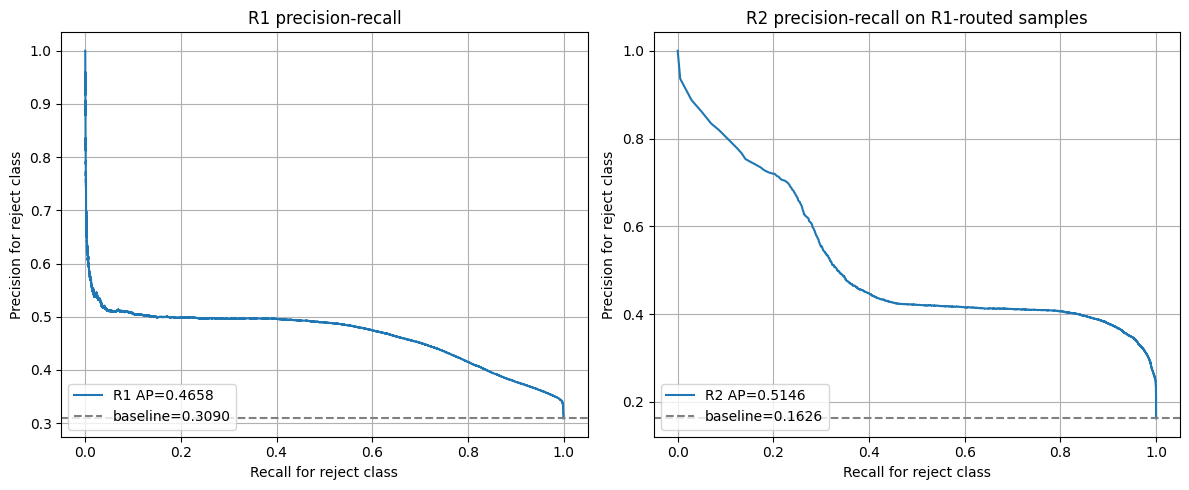

In [ ]:

r1_targets = (small_preds_np != labels_np).astype(int)
r2_targets = (mid_preds_np[r1_mask_np] != labels_np[r1_mask_np]).astype(int)

r1_precision, r1_recall, r1_ap = print_rejector_pr('R1', r1_targets, r1_scores_np)
r2_precision, r2_recall, r2_ap = print_rejector_pr('R2', r2_targets, r2_active_scores)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(r1_recall, r1_precision, label=f'R1 AP={r1_ap:.4f}')
axes[0].axhline(r1_targets.mean(), linestyle='--', color='gray', label=f'baseline={r1_targets.mean():.4f}')
axes[0].set_xlabel('Recall for reject class')
axes[0].set_ylabel('Precision for reject class')
axes[0].set_title('R1 precision-recall')
axes[0].grid(True)
axes[0].legend(loc='lower left')

axes[1].plot(r2_recall, r2_precision, label=f'R2 AP={r2_ap:.4f}')
axes[1].axhline(r2_targets.mean(), linestyle='--', color='gray', label=f'baseline={r2_targets.mean():.4f}')
axes[1].set_xlabel('Recall for reject class')
axes[1].set_ylabel('Precision for reject class')
axes[1].set_title('R2 precision-recall on R1-routed samples')
axes[1].grid(True)
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


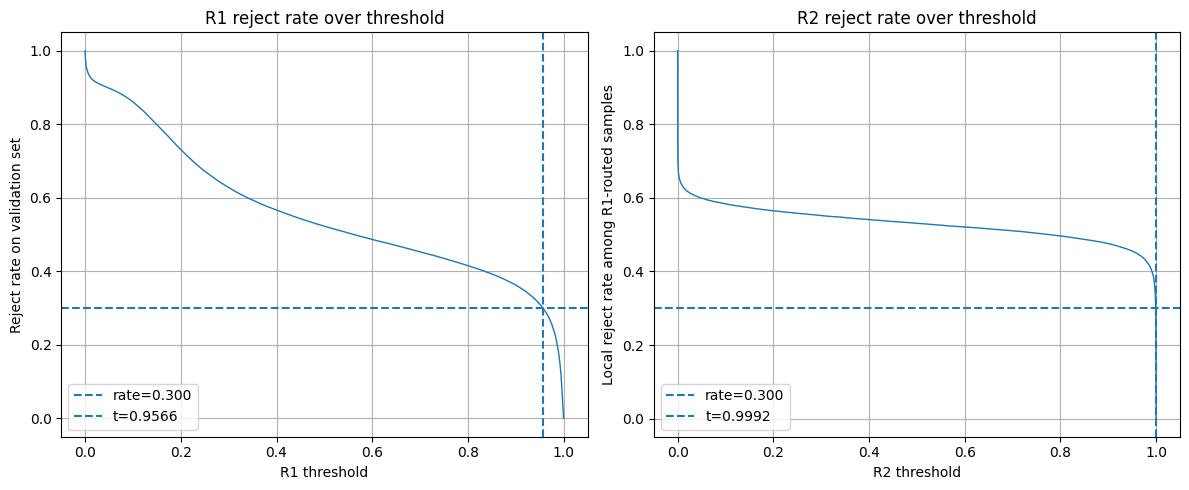

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

r1_threshold_grid = np.sort(np.unique(r1_scores_np))
r1_rate_grid = np.array([(r1_scores_np >= t).mean() for t in r1_threshold_grid])
axes[0].plot(r1_threshold_grid, r1_rate_grid, linewidth=1)
axes[0].axhline(selected_operating_point['r1_reject_rate'], linestyle='--', label=f"rate={selected_operating_point['r1_reject_rate']:.3f}")
axes[0].axvline(r1_threshold, linestyle='--', label=f't={r1_threshold:.4f}')
axes[0].set_xlabel('R1 threshold')
axes[0].set_ylabel('Reject rate on validation set')
axes[0].set_title('R1 reject rate over threshold')
axes[0].grid(True)
axes[0].legend()

r2_threshold_grid = np.sort(np.unique(r2_active_scores))
r2_rate_grid = np.array([(r2_active_scores >= t).mean() for t in r2_threshold_grid])
axes[1].plot(r2_threshold_grid, r2_rate_grid, linewidth=1)
axes[1].axhline(selected_operating_point['r2_local_reject_rate'], linestyle='--', label=f"rate={selected_operating_point['r2_local_reject_rate']:.3f}")
axes[1].axvline(r2_threshold, linestyle='--', label=f't={r2_threshold:.4f}')
axes[1].set_xlabel('R2 threshold')
axes[1].set_ylabel('Local reject rate among R1-routed samples')
axes[1].set_title('R2 reject rate over threshold')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:

output_dir = PROJECT_ROOT / 'moe' / 'artifacts' / 'operating_points'
output_dir.mkdir(parents=True, exist_ok=True)
output_file = output_dir / 'moe_selected_r1_r2_thresholds_val.csv'
selected_df.to_csv(output_file, index=False)
print(f'Saved selected thresholds to {output_file}')


Saved selected thresholds to /cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/artifacts/operating_points/moe_selected_r1_r2_thresholds_val.csv


: 

: 